# Explore here

In [2]:
import requests 
# print(requests.__version__)
import pandas as pd
import sqlite3 
import matplotlib.pyplot as plt
import seaborn as sns


In [16]:
# ---- dowloding data -----

# url= "https://api.worldbank.org/v2/country/usa;chn;bra;bol;jpn"

url_array=["https://api.worldbank.org/v2/country/usa;chn;bra;bol;jpn/indicator/SP.POP.TOTL", "https://api.worldbank.org/v2/country/usa;chn;bra;bol;jpn/indicator/NY.GDP.PCAP.CD", "https://api.worldbank.org/v2/country/usa;chn;bra;bol;jpn/indicator/SP.DYN.LE00.IN" ]

session = requests.Session()
indicator_data = []

for u in url_array:

    print("\n--------------------------------")
    print("Indicator:", u)

    params = {
        "date": "2010:2024",
        "format": "json",
        "per_page": 50,
        "page": 1
    }

    
    first_response = session.get(u, params=params, timeout=60)
    first_response.raise_for_status()
    first_response = first_response.json()
    print(first_response[0])

    num_pages = int(first_response[0]["pages"])

    for page in range(1, num_pages + 1):

        params = {
            "date": "2010:2024",
            "format": "json",
            "per_page": 50,
            "page": page
        }

        response = session.get(u, params=params, timeout=60)
        print(f"Requesting page {page}")
        print("URL:", response.url)
        print("Status:", response.status_code)

        if response.status_code != 200:
            print(response.text)
            break
        
        response.raise_for_status()
        response = response.json()

        if len(response) > 1 and response[1]:
            indicator_data.extend(response[1])

print(len(indicator_data))
print(type(indicator_data))
print(type(indicator_data[1]))
print(indicator_data[:195])    
    


  



--------------------------------
Indicator: https://api.worldbank.org/v2/country/usa;chn;bra;bol;jpn/indicator/SP.POP.TOTL
{'page': 1, 'pages': 2, 'per_page': 50, 'total': 75, 'sourceid': '2', 'lastupdated': '2026-07-13'}
Requesting page 1
URL: https://api.worldbank.org/v2/country/usa;chn;bra;bol;jpn/indicator/SP.POP.TOTL?date=2010%3A2024&format=json&per_page=50&page=1
Status: 200
Requesting page 2
URL: https://api.worldbank.org/v2/country/usa;chn;bra;bol;jpn/indicator/SP.POP.TOTL?date=2010%3A2024&format=json&per_page=50&page=2
Status: 200

--------------------------------
Indicator: https://api.worldbank.org/v2/country/usa;chn;bra;bol;jpn/indicator/NY.GDP.PCAP.CD
{'page': 1, 'pages': 2, 'per_page': 50, 'total': 75, 'sourceid': '2', 'lastupdated': '2026-07-13'}
Requesting page 1
URL: https://api.worldbank.org/v2/country/usa;chn;bra;bol;jpn/indicator/NY.GDP.PCAP.CD?date=2010%3A2024&format=json&per_page=50&page=1
Status: 200
Requesting page 2
URL: https://api.worldbank.org/v2/country/us

In [20]:
# <!-- Create one table (DataFrame) per indicator to make country comparisons easier.

# Suggested columns for each table:
# country
# year
# value
# Minimum cleaning:
# Remove rows with null value when needed
# Convert year to integer
# Convert value to numeric -->


selective_df=[]

for row in indicator_data:
    # print(type(row))
    selective_df.append({
        "country": row["country"]["value"],
        "indicator": row["indicator"]["id"], 
        "year": int(row["date"]),
        "value": row["value"]
        })
    
    
# selective_df= pd.DataFrame(selective_df)
df = pd.DataFrame(selective_df)
df_pivot = df.pivot(
    index=["country", "year"],
    columns="indicator",
    values="value"
).reset_index()

df= df.sort_values(["country","year"], ascending=True)

selective_df_1=[]
for row in indicator_data:
    if row["indicator"]["id"]=="SP.POP.TOTL":
        selective_df_1.append({
            "country": row["country"]["value"],
            "SP.POP.TOTL": row["value"], 
            "year": int(row["date"]),
            })
selective_df_2=[]   
for row in indicator_data:
    if row["indicator"]["id"]=="SP.DYN.LE00.IN":
        selective_df_2.append({
            "country": row["country"]["value"],
            "SP.DYN.LE00.IN": row["value"], 
            "year": int(row["date"]),
            })

selective_df_3=[]   
for row in indicator_data:
    if row["indicator"]["id"]=="NY.GDP.PCAP.CD":
        selective_df_3.append({
            "country": row["country"]["value"],
            "NY.GDP.PCAP.CD": row["value"], 
            "year": int(row["date"]),
            })

df1 = pd.DataFrame(selective_df_1)
df2 = pd.DataFrame(selective_df_2)
df3 = pd.DataFrame(selective_df_3)

selective_df_tot = (
    df1.merge(df2, on=["country", "year"])
       .merge(df3, on=["country", "year"])
)

selective_df_tot = selective_df_tot.sort_values(
    ["country", "year"],
    ascending=True)

print(pd.DataFrame(selective_df))
print(df_pivot)
print(selective_df_tot)


           country       indicator  year         value
0          Bolivia     SP.POP.TOTL  2024  1.241332e+07
1          Bolivia     SP.POP.TOTL  2023  1.224416e+07
2          Bolivia     SP.POP.TOTL  2022  1.207715e+07
3          Bolivia     SP.POP.TOTL  2021  1.193736e+07
4          Bolivia     SP.POP.TOTL  2020  1.181630e+07
..             ...             ...   ...           ...
220  United States  SP.DYN.LE00.IN  2014  7.884146e+01
221  United States  SP.DYN.LE00.IN  2013  7.874146e+01
222  United States  SP.DYN.LE00.IN  2012  7.874146e+01
223  United States  SP.DYN.LE00.IN  2011  7.864146e+01
224  United States  SP.DYN.LE00.IN  2010  7.854146e+01

[225 rows x 4 columns]
indicator        country  year  NY.GDP.PCAP.CD  SP.DYN.LE00.IN  SP.POP.TOTL
0                Bolivia  2010     1929.783731       66.003000   10182345.0
1                Bolivia  2011     2315.521219       66.282000   10348929.0
2                Bolivia  2012     2575.598571       66.586000   10515807.0
3           

15
15


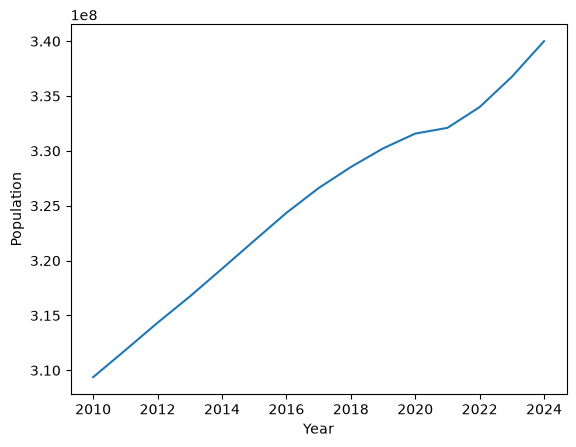

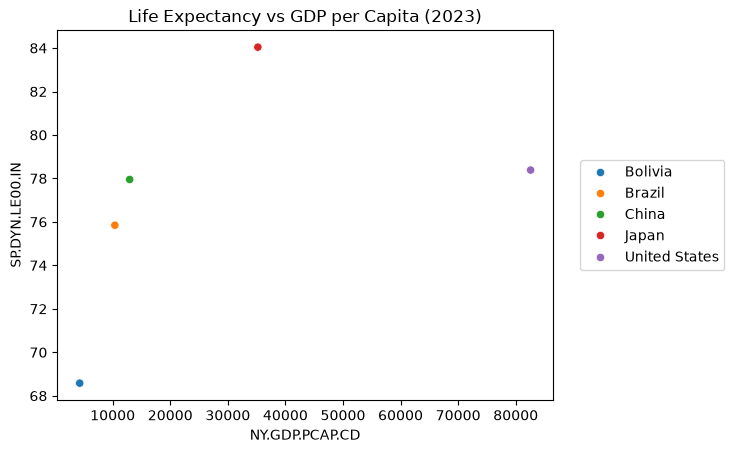

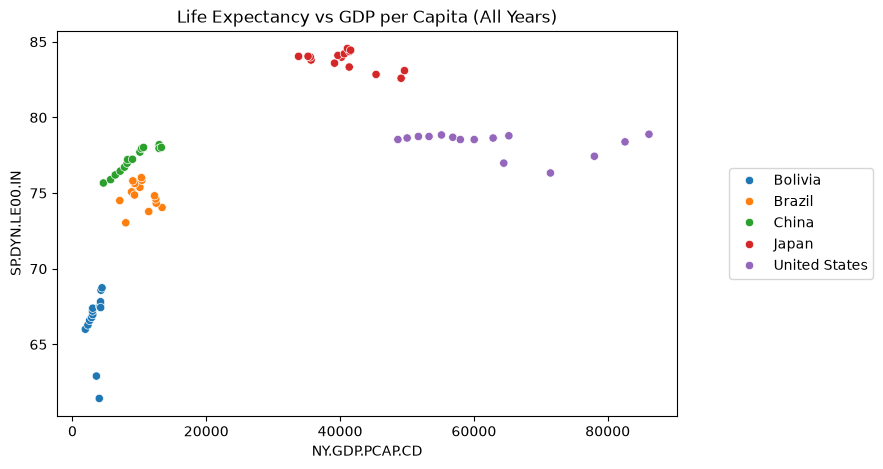

In [46]:
# ----- plotting using matplot lib -----
# Create at least 2 charts and explain findings in Markdown cells.
# Examples:

# Line chart: evolution of one indicator by country (2010-2024)
# Scatter plot: relationship between two indicators for a recent year

x= df_pivot[df_pivot["country"]=="United States"]["year"]
print(len(x))
y = df_pivot[(df_pivot["country"]=="United States")]["SP.POP.TOTL"]
print(len(y))
plt.plot(x, y)
plt.xlabel("Year")
plt.ylabel("Population")
plt.show()

#  check ---
# x_scat = df_pivot[df_pivot["year"]== 2023] ["NY.GDP.PCAP.CD"]
# print(len(x_scat))
# y_scat=  df_pivot[(df_pivot["year"]== 2023)] ["SP.DYN.LE00.IN"]
# print(len(y_scat))

# Graph 1: 2023 only
sns.scatterplot(
    data=df_pivot[df_pivot["year"] == 2023],
    x="NY.GDP.PCAP.CD",
    y="SP.DYN.LE00.IN",
    hue="country"
)
plt.legend(loc="center", bbox_to_anchor=(1.2, 0.5))
plt.title("Life Expectancy vs GDP per Capita (2023)")
plt.show()

# Graph 2: All years
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_pivot,
    x="NY.GDP.PCAP.CD",
    y="SP.DYN.LE00.IN",
    hue="country"
)
plt.legend(loc="center", bbox_to_anchor=(1.2, 0.5))
plt.title("Life Expectancy vs GDP per Capita (All Years)")
plt.show()





In [40]:
# use SQLite with SQLAlchemy to persist data:

# Database: world_bank_analysis.db
# Teaching recommendation: one table per indicator (example: indicator_gdp_per_capita, indicator_life_expectancy, etc.)
# Recommended flow:

# Create an engine with SQLAlchemy
# Save each DataFrame with to_sql(..., if_exists="replace")
# Read a sample with pd.read_sql() to validate the load

# ONE TABLE #
connection = sqlite3.connect("world_bank_analysis.db")
df_pivot.to_sql(
    "indicator",
    connection,
    if_exists="replace",
    index=False
)
print(pd.read_sql("SELECT * FROM indicator LIMIT 5", connection))
# connection.close()

#  three different tables for three indicator #
# conection= sqlite3.connect("world_bank_analysis.db")
df1.to_sql("population", connection,if_exists="replace",
    index=False )
df2.to_sql("life expectancy", connection, if_exists="replace",
    index=False )
df3.to_sql("gdp per capita", connection, if_exists="replace",
    index=False )

print(pd.read_sql("SELECT * FROM population LIMIT 5", connection))
print(pd.read_sql("SELECT * FROM 'life expectancy' LIMIT 5", connection))
print(pd.read_sql("SELECT * FROM 'gdp per capita' LIMIT 5", connection))

print(pd.read_sql("""
SELECT p.country, p.year, p.'SP.POP.TOTL', le.'SP.DYN.LE00.IN', gpc.'NY.GDP.PCAP.CD'
FROM population AS p
LEFT JOIN "life expectancy" AS le
ON p.country = le.country 
AND p.year = le.year
LEFT JOIN "gdp per capita" AS gpc
ON p.country = gpc.country 
AND p.year = gpc.year
LIMIT 5
""", connection))


connection.close()


   country  year  NY.GDP.PCAP.CD  SP.DYN.LE00.IN  SP.POP.TOTL
0  Bolivia  2010     1929.783731          66.003   10182345.0
1  Bolivia  2011     2315.521219          66.282   10348929.0
2  Bolivia  2012     2575.598571          66.586   10515807.0
3  Bolivia  2013     2870.023770          66.777   10682608.0
4  Bolivia  2014     3041.435032          66.970   10848888.0
   country  SP.POP.TOTL  year
0  Bolivia     12413315  2024
1  Bolivia     12244159  2023
2  Bolivia     12077154  2022
3  Bolivia     11937360  2021
4  Bolivia     11816299  2020
   country  SP.DYN.LE00.IN  year
0  Bolivia          68.739  2024
1  Bolivia          68.581  2023
2  Bolivia          67.434  2022
3  Bolivia          61.427  2021
4  Bolivia          62.906  2020
   country  NY.GDP.PCAP.CD  year
0  Bolivia     4421.166099  2024
1  Bolivia     4274.708205  2023
2  Bolivia     4219.461137  2022
3  Bolivia     4010.760537  2021
4  Bolivia     3580.967618  2020
   country  year  SP.POP.TOTL  SP.DYN.LE00.IN  NY.GD